# VISET

> **Vis**ual **I**temized **SET** diagrams: area-proportional Venn/Euler and UpSet plots that print the **member names** inside each region, in Python.

Venn/Euler diagrams read best for **2 to 3 sets**; **UpSet** takes over when there are more. Below, both are drawn on drug-target sets, each as a static (Matplotlib) and an interactive (Plotly) figure. Every region or bar lists the actual genes. When an intersection is too small to print its members legibly, reach for the **interactive** (Plotly) version and hover the region to read them.

## Venn / Euler (three drugs)

**Static** (Matplotlib): proportional ellipses, every gene printed and auto-sized to fit its region.

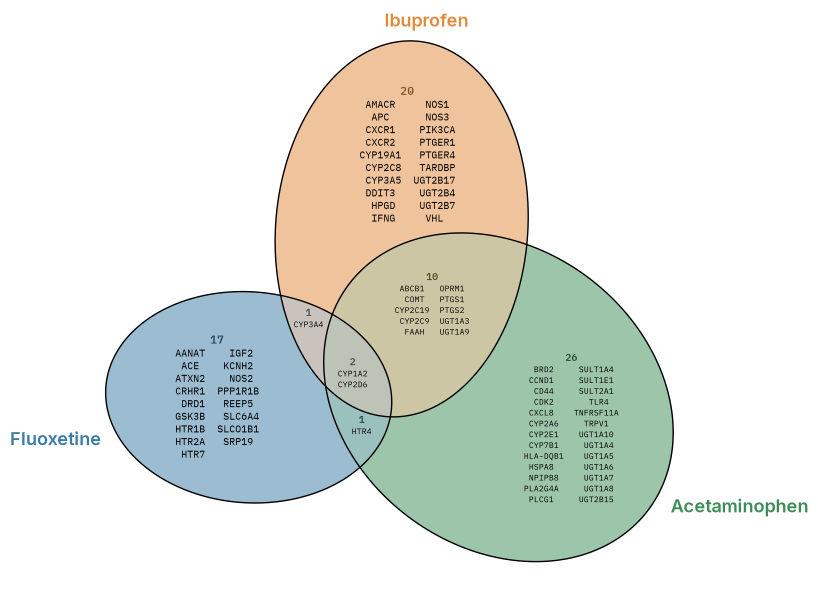

In [1]:
#| code-fold: true
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager
from viset import load, eunoia_venn
fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
db = "Drug target sample files/" if os.path.isdir("Drug target sample files") else "../Drug target sample files/"
def L(name, fname): return load(db + fname, "Gene names", name)
flx = L("Fluoxetine", "1. FLUOXETINE_sample.csv")
ibu = L("Ibuprofen", "2. IBUPROFEN_sample.csv")
ace = L("Acetaminophen", "3. ACETAMINOPHEN_sample.csv")
eunoia_venn([flx, ibu, ace], colors=["#3a7ca5", "#e08a3c", "#3c8c57"], style="round", title="", figsize=(8.5, 7.5), margin=0.06, seed=0)

**Interactive** (Plotly): hover any region to read its members — the option to reach for when an intersection is too small for the static figure to fit its labels.

In [2]:
#| code-fold: true
import os
import plotly.io as pio
pio.renderers.default = "notebook_connected"
from matplotlib import font_manager
from viset import load, eunoia_venn_interactive
fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
db = "Drug target sample files/" if os.path.isdir("Drug target sample files") else "../Drug target sample files/"
def L(name, fname): return load(db + fname, "Gene names", name)
flx = L("Fluoxetine", "1. FLUOXETINE_sample.csv")
ibu = L("Ibuprofen", "2. IBUPROFEN_sample.csv")
ace = L("Acetaminophen", "3. ACETAMINOPHEN_sample.csv")
eunoia_venn_interactive([flx, ibu, ace], colors=["#3a7ca5", "#e08a3c", "#3c8c57"], width=760, height=680, title="", seed=0)

## UpSet (four drugs)

**Static** (Matplotlib): one bar per intersection with its members listed inside, so it keeps working past the three-set limit of a Venn.

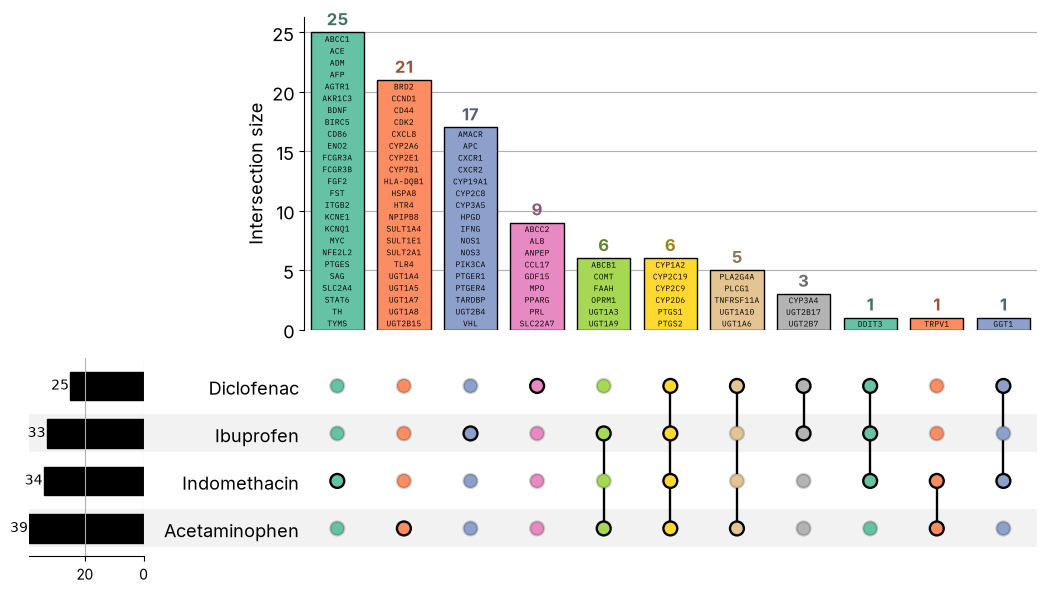

In [3]:
#| code-fold: true
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager
from viset import load, upset
fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
db = "Drug target sample files/" if os.path.isdir("Drug target sample files") else "../Drug target sample files/"
def L(name, fname): return load(db + fname, "Gene names", name)
ibu = L("Ibuprofen", "2. IBUPROFEN_sample.csv")
ace = L("Acetaminophen", "3. ACETAMINOPHEN_sample.csv")
dic = L("Diclofenac", "12. DICLOFENAC_sample.csv")
ind = L("Indomethacin", "13. INDOMETHACIN_sample.csv")
upset({"Ibuprofen": ibu, "Acetaminophen": ace, "Diclofenac": dic, "Indomethacin": ind},
      figsize=(13, 7), color_list="Set2", wspace=0.5)

**Interactive** (Plotly): hover any bar to read its members.

In [4]:
#| code-fold: true
import os
import plotly.io as pio
pio.renderers.default = "notebook_connected"
from matplotlib import font_manager
from viset import load, upset_interactive
fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
db = "Drug target sample files/" if os.path.isdir("Drug target sample files") else "../Drug target sample files/"
def L(name, fname): return load(db + fname, "Gene names", name)
ibu = L("Ibuprofen", "2. IBUPROFEN_sample.csv")
ace = L("Acetaminophen", "3. ACETAMINOPHEN_sample.csv")
dic = L("Diclofenac", "12. DICLOFENAC_sample.csv")
ind = L("Indomethacin", "13. INDOMETHACIN_sample.csv")
upset_interactive({"Ibuprofen": ibu, "Acetaminophen": ace, "Diclofenac": dic, "Indomethacin": ind}, wspace = 0.5, 
                  title="", color_list="Set2", figsize=(11, 6.5))

Want the reasoning behind all this? See [State of current set diagrams](state_of_set_diagrams.html) for the existing tools and their gaps, and the [Introduction](introduction.html) to install VISET and run it on your own data. Full-page interactive versions: [Venn](venn_interactive.html) and [UpSet](upset_interactive.html).